# Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import matplotlib.patches as patches

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
from collections import Counter

import gseapy as gp
import os

# DATA

In [ ]:
dnv = pd.read_feather('/path/to/data/variant.csv')
label = pd.read_csv("/path/to/data/label.csv")

In [ ]:
ATTN_ROOT = "/path/to/attn"

# DNABERT
zs_dnabert_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert_zs_attn.csv")
ft_dnabert_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_ncre_attn.csv")
ft_dnabert_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_bend_attn.csv")
ft_dnabert_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_clinvar_attn.csv")
ft_dnabert_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_gnomad_attn.csv")

# DNABERT2
zs_dnabert2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert2_zs_attn.csv")
ft_dnabert2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_ncre_attn.csv")
ft_dnabert2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_bend_attn.csv")
ft_dnabert2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_clinvar_attn.csv")
ft_dnabert2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_gnomad_attn.csv")

# NTv2
zs_ntv2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv2_zs_attn.csv")
ft_ntv2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_ncre_attn.csv")
ft_ntv2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_bend_attn.csv")
ft_ntv2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_clinvar_attn.csv")
ft_ntv2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_gnomad_attn.csv")

# NTv3
zs_ntv3_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv3_zs_attn.csv")
ft_ntv3_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_ncre_attn.csv")
ft_ntv3_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_bend_attn.csv")
ft_ntv3_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_clinvar_attn.csv")
ft_ntv3_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_gnomad_attn.csv")

# HyenaDNA
zs_hyena_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/hyenadna_zs_attn.csv")
ft_hyena_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_ncre_attn.csv")
ft_hyena_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_bend_attn.csv")
ft_hyena_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_clinvar_attn.csv")
ft_hyena_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_gnomad_attn.csv")

# evo2
zs_evo2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/evo2_zs_attn.csv")
ft_evo2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_ncre_attn.csv")
ft_evo2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_bend_attn.csv")
ft_evo2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_clinvar_attn.csv")
ft_evo2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_gnomad_attn.csv")

# PhyloGPN
zs_phylogpn_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/phylogpn_zs_attn.csv")
ft_phylogpn_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_ncre_attn.csv")
ft_phylogpn_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_bend_attn.csv")
ft_phylogpn_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_clinvar_attn.csv")
ft_phylogpn_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_gnomad_attn.csv")

model_tasks_attn = {
    "DNABERT":  {"ZS": zs_dnabert_attn,  "NCRE": ft_dnabert_ncre_attn,  "BEND": ft_dnabert_bend_attn,  "ClinVar": ft_dnabert_clinvar_attn,  "gnomAD": ft_dnabert_gnomad_attn},
    "DNABERT2": {"ZS": zs_dnabert2_attn, "NCRE": ft_dnabert2_ncre_attn, "BEND": ft_dnabert2_bend_attn, "ClinVar": ft_dnabert2_clinvar_attn, "gnomAD": ft_dnabert2_gnomad_attn},
    "NTv2":     {"ZS": zs_ntv2_attn,     "NCRE": ft_ntv2_ncre_attn,     "BEND": ft_ntv2_bend_attn,     "ClinVar": ft_ntv2_clinvar_attn,     "gnomAD": ft_ntv2_gnomad_attn},
    "NTv3":     {"ZS": zs_ntv3_attn,     "NCRE": ft_ntv3_ncre_attn,     "BEND": ft_ntv3_bend_attn,     "ClinVar": ft_ntv3_clinvar_attn,     "gnomAD": ft_ntv3_gnomad_attn},
    "HyenaDNA": {"ZS": zs_hyena_attn,    "NCRE": ft_hyena_ncre_attn,    "BEND": ft_hyena_bend_attn,    "ClinVar": ft_hyena_clinvar_attn,    "gnomAD": ft_hyena_gnomad_attn},
    "Evo 2": {"ZS": zs_evo2_attn,    "NCRE": ft_evo2_ncre_attn,    "BEND": ft_evo2_bend_attn,    "ClinVar": ft_evo2_clinvar_attn,    "gnomAD": ft_evo2_gnomad_attn},
    "PhyloGPN": {"ZS": zs_phylogpn_attn, "NCRE": ft_phylogpn_ncre_attn, "BEND": ft_phylogpn_bend_attn, "ClinVar": ft_phylogpn_clinvar_attn, "gnomAD": ft_phylogpn_gnomad_attn},
}

In [ ]:
tasks  = ['ZS', 'ClinVar', 'gnomAD', 'BEND', 'NCRE']
models = ['DNABERT', 'DNABERT2', 'NTv2', 'NTv3', 'HyenaDNA', 'Evo 2', 'PhyloGPN']

model_labels = {
    'DNABERT'  : 'DNABERT',
    'DNABERT2' : 'DNABERT-2',
    'NTv2'     : 'Nucleotide\nTransformer V2',
    'NTv3'     : 'Nucleotide\nTransformer V3',
    'HyenaDNA' : 'HyenaDNA',
    'Evo 2' : 'Evo 2',
    'PhyloGPN' : 'PhyloGPN',
}

task_labels = {
    'ZS'     : 'Zero-shot',
    'ClinVar': 'ClinVar Missense Variants',
    'gnomAD' : 'gnomAD Variants',
    'BEND'   : 'BEND Non-coding Variants',
    'NCRE'   : 'Non-coding Regulatory Elements',
}

def parse_gene_ratio(overlap_str):
    a, b = overlap_str.split('/')
    return int(a) / int(b)


# CLR Function

In [ ]:
ATTN_COL         = "attention"
CLR_COL          = "attention_clr"
PSEUDOCOUNT      = 1e-12
NORMALIZE_IN_SAMPLE = True
TOP_FRAC         = 0.10

In [ ]:
def clr_transform_by_sample(df):

    df = df.copy()
    df = df.dropna(subset=["vcf_iid", ATTN_COL])
    df["vcf_iid"] = df["vcf_iid"].astype(str)

    df[ATTN_COL] = np.clip(
        pd.to_numeric(df[ATTN_COL], errors="coerce"),
        0,
        None
    )

    def _clr(g):

        x = g[ATTN_COL].to_numpy(dtype=float)

        if NORMALIZE_IN_SAMPLE:
            s = x.sum()
            if (not np.isfinite(s)) or s <= 0:
                g[CLR_COL] = 0.0
                return g
            x = x / s

        x = x + PSEUDOCOUNT
        lx = np.log(x)
        g[CLR_COL] = lx - lx.mean()
        return g

    return df.groupby("vcf_iid", group_keys=False).apply(_clr)

# Preprocessing

In [ ]:
# ── gene mapping dnv ───────────────────────────────────
dnv_gene = dnv[dnv['gene_symbol'].notna()][['vcf_iid', 'variant', 'gene_symbol']].copy()
dnv_gene['vcf_iid'] = dnv_gene['vcf_iid'].astype(str)

In [ ]:
# ## subgroup

# # ── ASD ───────────────────────────
# asd_samples = set(label[label['Group'] == "Autism"]['vcf_iid'].astype(str))
# print(f"ASD: {len(asd_samples)}")

# # ── ctrl ───────────────────────────
# ctrl_samples = set(label[label['Group'] == "Control"]['vcf_iid'].astype(str))
# print(f"ctrl: {len(ctrl_samples)}")

In [10]:
gene_list_dict_attn_high = {}
gene_list_dict_attn_low  = {}

for model, tasks in model_tasks_attn.items():
    for task, attn_df in tasks.items():
        col_name = f"{model}_{task}"

        # all test samples
        attn_all = attn_df.copy()
        attn_all['vcf_iid'] = attn_all['vcf_iid'].astype(str)

        # # only ASD
        # attn_asd = attn_df[attn_df['vcf_iid'].astype(str).isin(asd_samples)].copy()
        # attn_asd['vcf_iid'] = attn_asd['vcf_iid'].astype(str)

        # # only ctrl
        # attn_ctrl = attn_df[attn_df['vcf_iid'].astype(str).isin(ctrl_samples)].copy()
        # attn_ctrl['vcf_iid'] = attn_ctrl['vcf_iid'].astype(str)

        attn_clr = clr_transform_by_sample(attn_all)

        n_top = int(np.ceil(len(attn_clr) * TOP_FRAC))
        top_thresh = attn_clr[CLR_COL].nlargest(n_top).min()
        bot_thresh = attn_clr[CLR_COL].nsmallest(n_top).max()

        high = attn_clr[attn_clr[CLR_COL] >= top_thresh].copy()
        low  = attn_clr[attn_clr[CLR_COL] <= bot_thresh].copy()

        high_gene = high.merge(dnv_gene, on=['vcf_iid', 'variant'], how='inner')
        low_gene  = low.merge(dnv_gene,  on=['vcf_iid', 'variant'], how='inner')

        def get_recurrent_genes(df):
            variant_cnt = (
                df.groupby('gene_symbol')['variant']
                .nunique()
                .reset_index()
                .rename(columns={'variant': 'variant_cnt'})
            )
            sample_cnt = (
                df.groupby('gene_symbol')['vcf_iid']
                .nunique()
                .reset_index()
                .rename(columns={'vcf_iid': 'sample_cnt'})
            )
            merged = variant_cnt.merge(sample_cnt, on='gene_symbol')
            return merged[
                (merged['variant_cnt'] >= 2) & (merged['sample_cnt'] >= 2)
            ]['gene_symbol'].tolist()

        gene_list_dict_attn_high[col_name] = get_recurrent_genes(high_gene)
        gene_list_dict_attn_low[col_name]  = get_recurrent_genes(low_gene)

        print(f"{col_name:<22} ctrl={len(attn_all['vcf_iid'].unique()):>4} | "
              f"high_genes={len(gene_list_dict_attn_high[col_name]):>4} | "
              f"low_genes={len(gene_list_dict_attn_low[col_name]):>4}")

/tmp/ipykernel_52178/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


DNABERT_ZS             ctrl=1529 | high_genes=1025 | low_genes=1122


/tmp/ipykernel_52178/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


DNABERT_NCRE           ctrl=1529 | high_genes=1032 | low_genes=1048


/tmp/ipykernel_52178/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


...

PhyloGPN_BEND          ctrl=1529 | high_genes= 946 | low_genes=1142


/tmp/ipykernel_52178/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


PhyloGPN_ClinVar       ctrl=1529 | high_genes=1010 | low_genes=1185


/tmp/ipykernel_52178/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


PhyloGPN_gnomAD        ctrl=1529 | high_genes= 964 | low_genes=1127


# GSEApy Enrichr

In [11]:
# ── GO BP Enrichment ─────────────────────────────────────────
results_enrich_attn_high = {}
results_enrich_attn_low  = {}

for col_name, genes in gene_list_dict_attn_high.items():
    if len(genes) == 0:
        print(f"{col_name}: None gene list, skip")
        continue
    try:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2025',
            organism='human',
            outdir=None,
            verbose=False
        )
        results_enrich_attn_high[col_name] = enr.results
        print(f"{col_name}: success, ({len(genes)} gene)")
    except Exception as e:
        print(f"{col_name}: failure → {e}")

for col_name, genes in gene_list_dict_attn_low.items():
    if len(genes) == 0:
        print(f"{col_name}: None gene list, skip")
        continue
    try:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2025',
            organism='human',
            outdir=None,
            verbose=False
        )
        results_enrich_attn_low[col_name] = enr.results
        print(f"{col_name}: success, ({len(genes)} gene)")
    except Exception as e:
        print(f"{col_name}: failure → {e}")

DNABERT_ZS: success, (1025 gene)
DNABERT_NCRE: success, (1032 gene)
DNABERT_BEND: success, (982 gene)
DNABERT_ClinVar: success, (1020 gene)
DNABERT_gnomAD: success, (993 gene)
DNABERT2_ZS: success, (969 gene)
DNABERT2_NCRE: success, (1014 gene)
DNABERT2_BEND: success, (971 gene)
DNABERT2_ClinVar: success, (961 gene)
DNABERT2_gnomAD: success, (1042 gene)
NTv2_ZS: success, (981 gene)
NTv2_NCRE: success, (1022 gene)
NTv2_BEND: success, (1013 gene)
NTv2_ClinVar: success, (1017 gene)
NTv2_gnomAD: success, (1020 gene)
NTv3_ZS: success, (1029 gene)
NTv3_NCRE: success, (1005 gene)
NTv3_BEND: success, (1021 gene)
NTv3_ClinVar: success, (994 gene)
NTv3_gnomAD: success, (1019 gene)
HyenaDNA_ZS: success, (1014 gene)
HyenaDNA_NCRE: success, (1018 gene)
HyenaDNA_BEND: success, (1027 gene)
HyenaDNA_ClinVar: success, (979 gene)
HyenaDNA_gnomAD: success, (976 gene)
Evo 2_ZS: success, (1022 gene)
Evo 2_NCRE: success, (1017 gene)
Evo 2_BEND: success, (1024 gene)
Evo 2_ClinVar: success, (1017 gene)
Evo 2_

# Visualization

In [12]:
tasks = ['ZS', 'ClinVar', 'gnomAD', 'BEND', 'NCRE'] 

target_terms_attn = [
    # ── circuit ──────────────────────────────────────────────
    'Neuron Projection Guidance (GO:0097485)',
    'Axon Guidance (GO:0007411)',
    'Axonogenesis (GO:0007409)',
    'Nervous System Development (GO:0007399)',
    # ── synapse / signaling ───────────────────────────────────
    'Homophilic Cell Adhesion via Plasma Membrane Adhesion Molecules (GO:0007156)',
    'Regulation of Trans-Synaptic Signaling (GO:0099177)',
]

0
5.954528604090756


/tmp/ipykernel_52178/400508745.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.95])


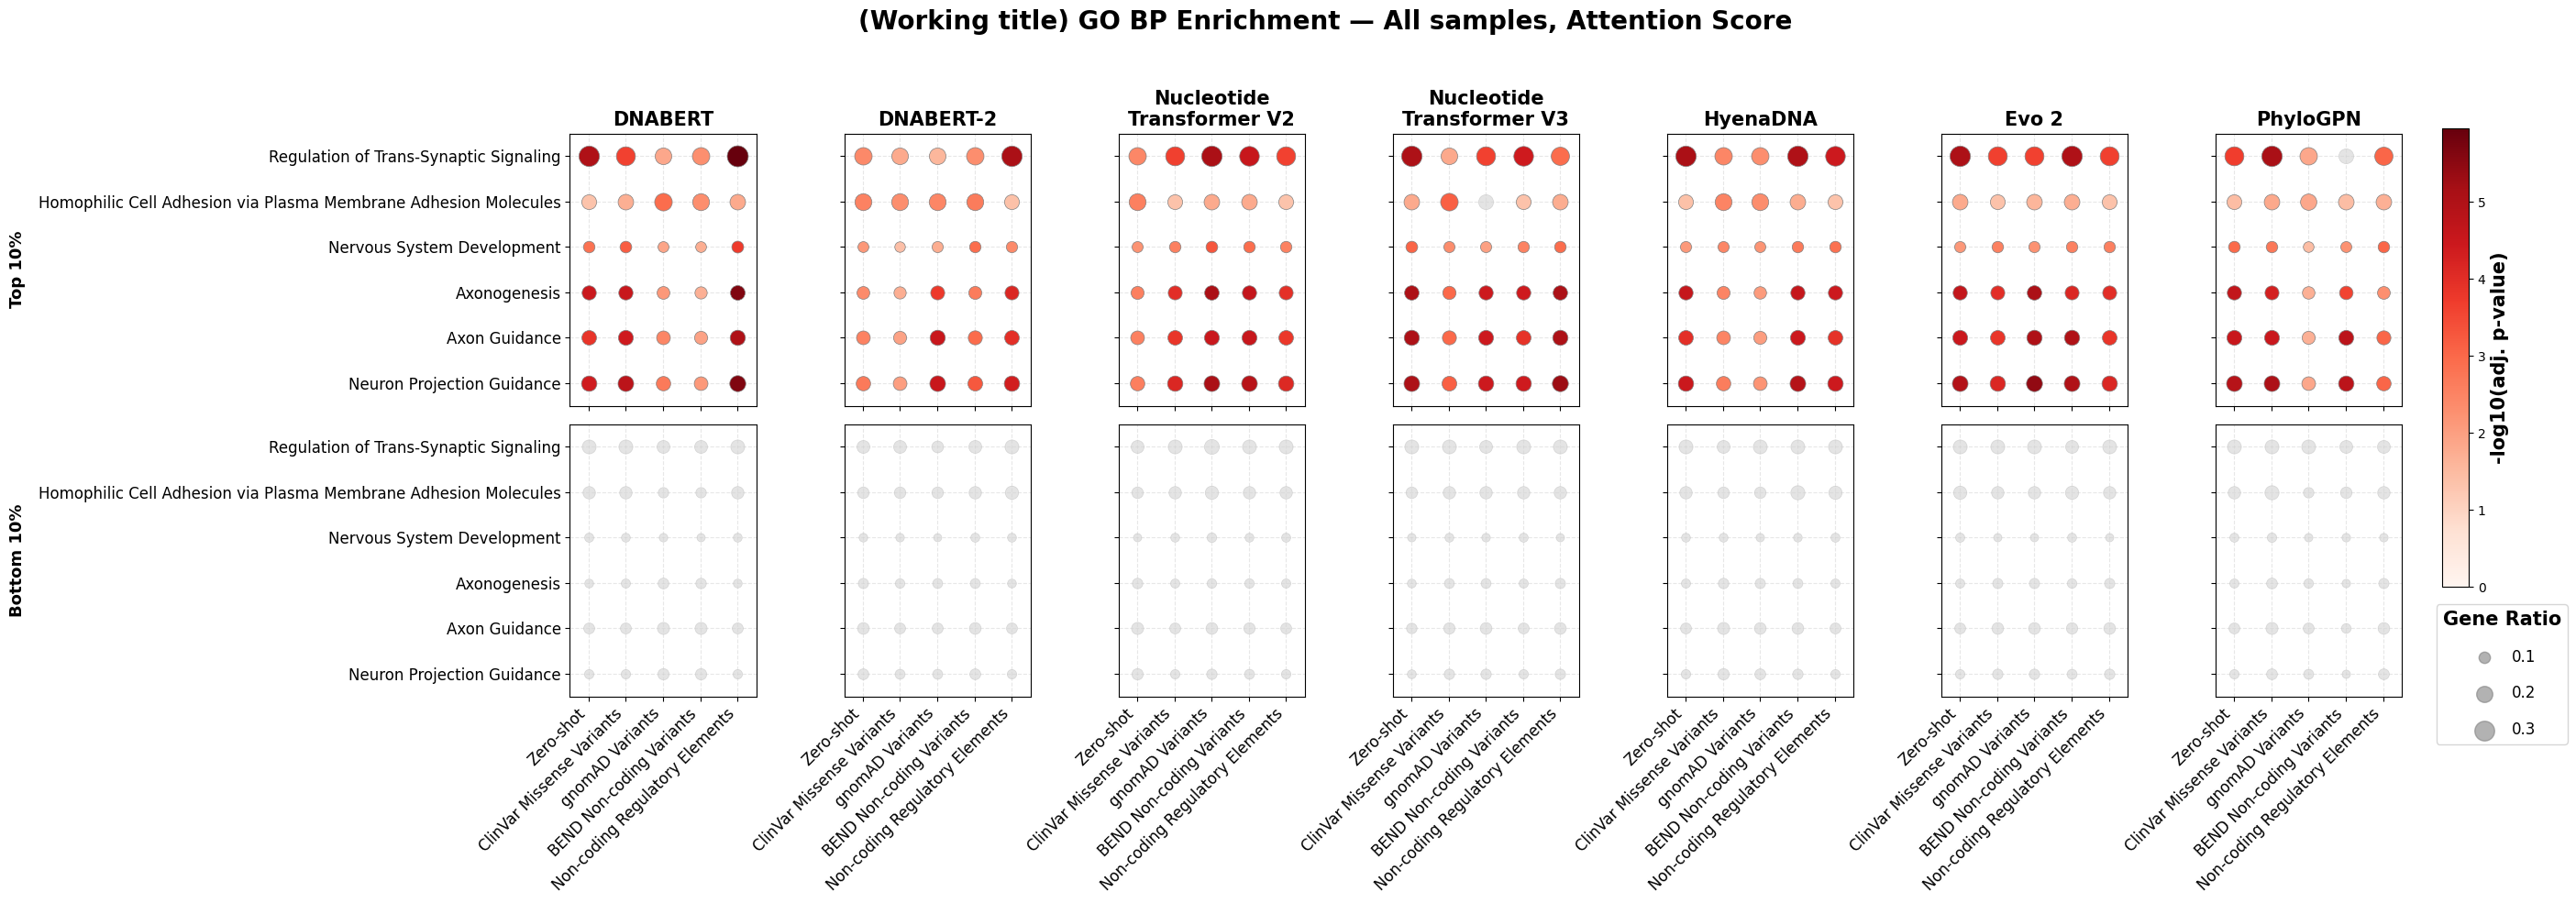

In [13]:
all_logp = []
for model in models:
    for task in tasks:
        key = f"{model}_{task}"
        for results in [results_enrich_attn_high, results_enrich_attn_low]:
            if key not in results:
                continue
            df = results[key]
            for term in target_terms_attn:
                row = df[df['Term'] == term]
                if len(row) > 0 and row['Adjusted P-value'].values[0] < 0.05:
                    p = row['Adjusted P-value'].values[0]
                    all_logp.append(-np.log10(p + 1e-300))

# vmin, vmax = 0, 6.088243942223694                 # If you set it the same as the asd version

vmin, vmax = 0, (max(all_logp) if all_logp else 1)
print(vmin)
print(vmax)

fig, axes = plt.subplots(2, 7, figsize=(29, 10), sharey=True, sharex=True)

for col, model in enumerate(models):
    for row_idx, (results, label_suffix) in enumerate([
        (results_enrich_attn_high, 'Top 10%'),
        (results_enrich_attn_low,  'Bottom 10%')
    ]):
        ax = axes[row_idx][col]

        for j, task in enumerate(tasks):
            key = f"{model}_{task}"
            if key not in results:
                continue
            df = results[key]

            for i, term in enumerate(target_terms_attn):
                row = df[df['Term'] == term]
                if len(row) == 0:
                    continue

                adj_p      = row['Adjusted P-value'].values[0]
                gene_ratio = parse_gene_ratio(row['Overlap'].values[0])
                logp       = -np.log10(adj_p + 1e-300)

                if adj_p < 0.05:
                    ax.scatter(j, i, s=gene_ratio * 800, c=logp,
                               cmap='Reds', vmin=vmin, vmax=vmax,
                               edgecolors='grey', linewidths=0.5, zorder=3)
                else:
                    ax.scatter(j, i, s=gene_ratio * 800,
                               color='lightgrey', edgecolors='silver',
                               linewidths=0.5, alpha=0.6, zorder=2)

        ax.set_xlim(-0.5, len(tasks) - 0.5)
        ax.set_ylim(-0.5, len(target_terms_attn) - 0.5)
        ax.grid(True, alpha=0.3, linestyle='--')

        if row_idx == 0:
            ax.set_title(model_labels[model], fontsize=15, fontweight='bold')

        ax.set_xticks(range(len(tasks)))
        if row_idx == 1:
            ax.set_xticklabels([task_labels[t] for t in tasks], fontsize=12, rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        ax.set_yticks(range(len(target_terms_attn)))
        if col == 0:
            ax.set_yticklabels([t.split(' (GO')[0] for t in target_terms_attn], fontsize=12)

        if col == 0:
            ax.set_ylabel(label_suffix, fontsize=13, fontweight='bold', labelpad=10)

cbar_ax = fig.add_axes([0.92, 0.35, 0.01, 0.5])
sm = plt.cm.ScalarMappable(cmap='Reds', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(adj. p-value)', fontsize=15, fontweight='bold')

legend_ratios = [0.1, 0.2, 0.3]
legend_handles = [plt.scatter([], [], s=r*800, c='grey', alpha=0.6, label=f'{r:.1f}') for r in legend_ratios]


leg = fig.legend(handles=legend_handles, title='Gene Ratio', loc='lower right',
                 bbox_to_anchor=(0.97, 0.17), fontsize=12, title_fontsize=15,
                 frameon=True, labelspacing=1.3)
leg.get_title().set_fontweight('bold')

fig.suptitle('(Working title) GO BP Enrichment — All samples, Attention Score',
             fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.91, 0.95])
plt.show()